<div style="background:linear-gradient(135deg,#4a044e 0%,#a21caf 55%,#e879f9 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#f5d0fe;font-weight:700;text-transform:uppercase">Chapter 144 · Advanced &amp; Applied Topics</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Survival Analysis</div>
  <div style="font-size:15px;color:#fae8ff;max-width:740px;line-height:1.6">Half these subscribers are still active, so their tenure is censored, not missing. We estimate a Kaplan-Meier survival curve that uses them, compare contract types with a log-rank test, and fit a Cox model for adjusted hazard ratios, all with statsmodels.</div>
</div>

Run top to bottom. Uses **pandas** and **statsmodels** (`SurvfuncRight`, `survdiff`, `PHReg`). The popular `lifelines` library is a fine alternative with the same ideas.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from statsmodels.duration.survfunc import SurvfuncRight, survdiff
from statsmodels.duration.hazard_regression import PHReg
plt.rcParams.update({"figure.dpi":110,"axes.grid":True,"grid.alpha":0.25,"font.size":11})
FU, GR, BL = "#a21caf", "#16a34a", "#2563eb"
BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "survival-analysis--subscription-churn.xlsx"
try:
    df = pd.read_excel("../../data/" + fn)
except FileNotFoundError:
    df = pd.read_excel(BASE + fn)
print(df.shape); print(df.head())

def St(sf, t):                       # survival probability at time t from a fitted KM curve
    i = np.searchsorted(sf.surv_times, t, side="right") - 1
    return 1.0 if i < 0 else float(sf.surv_prob[i])
def median_surv(sf):                 # smallest time where S(t) <= 0.5 (nan if never reached)
    below = sf.surv_times[sf.surv_prob <= 0.5]
    return float(below[0]) if len(below) else np.nan

(1000, 5)
  customer_id        contract  monthly_charges  tenure_months  churned
0     S300000          annual            63.80          24.00        0
1     S300001          annual            56.36          24.00        0
2     S300002          annual            87.30          24.00        0
3     S300003  month-to-month            86.68          12.97        1
4     S300004          annual            77.71           2.77        1


## DEMO 1 &middot; Censoring: why a naive average lies
The event flag `churned` is 1 for a real churn and 0 for a customer still active at the 24-month cutoff (censored). Averaging only the churners, or everyone, both mislead. Only a survival estimate uses the censored rows correctly.

In [2]:
n = len(df); ev = int(df.churned.sum())
print(f"{n} subscribers | {ev} churned ({ev/n:.1%}) | {n-ev} censored (still active)")
naive_churned = df.loc[df.churned==1, "tenure_months"].mean()
naive_all     = df["tenure_months"].mean()
print(f"naive mean tenure, churned only : {naive_churned:.1f} months  (ignores the loyal, biased LOW)")
print(f"naive mean tenure, everyone      : {naive_all:.1f} months  (treats censored as if they churned, biased LOW)")
sf_all = SurvfuncRight(df.tenure_months, df.churned)
print(f"Kaplan-Meier median survival     : {median_surv(sf_all):.1f} months  (uses censoring correctly)")

1000 subscribers | 487 churned (48.7%) | 513 censored (still active)
naive mean tenure, churned only : 9.6 months  (ignores the loyal, biased LOW)
naive mean tenure, everyone      : 14.9 months  (treats censored as if they churned, biased LOW)
Kaplan-Meier median survival     : 20.9 months  (uses censoring correctly)


## DEMO 2 &middot; The Kaplan-Meier survival curve
S(t) is a staircase: flat between events, dropping at each churn, with the censored customers quietly leaving the at-risk set. Read the probability of still being subscribed at 6, 12, and 24 months straight off it.

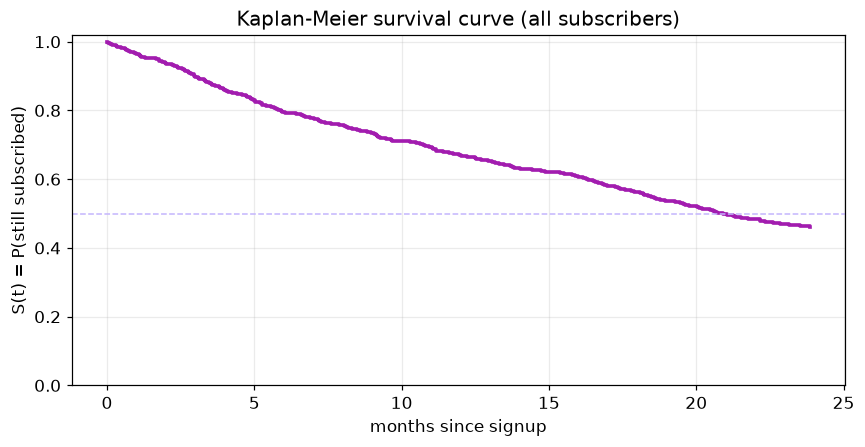

S( 6 months) = 0.80
S(12 months) = 0.67
S(24 months) = 0.46


In [3]:
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.step(np.r_[0, sf_all.surv_times], np.r_[1, sf_all.surv_prob], where="post", color=FU, lw=2.4)
ci_lo, ci_hi = sf_all.surv_prob_ci if hasattr(sf_all, "surv_prob_ci") else (None, None)
ax.axhline(0.5, color="#c4b5fd", ls="--", lw=1)
ax.set_xlabel("months since signup"); ax.set_ylabel("S(t) = P(still subscribed)")
ax.set_title("Kaplan-Meier survival curve (all subscribers)"); ax.set_ylim(0, 1.02)
plt.tight_layout(); plt.show()
for t in [6, 12, 24]:
    print(f"S({t:2d} months) = {St(sf_all, t):.2f}")

## DEMO 3 &middot; Compare contracts with a log-rank test
Split the curve by contract type. If the two survival curves separate, the log-rank test tells you whether the gap is real across all event times, not just at one snapshot.

annual          : S(12mo) = 0.77, median = nan
month-to-month  : S(12mo) = 0.58, median = 16.24


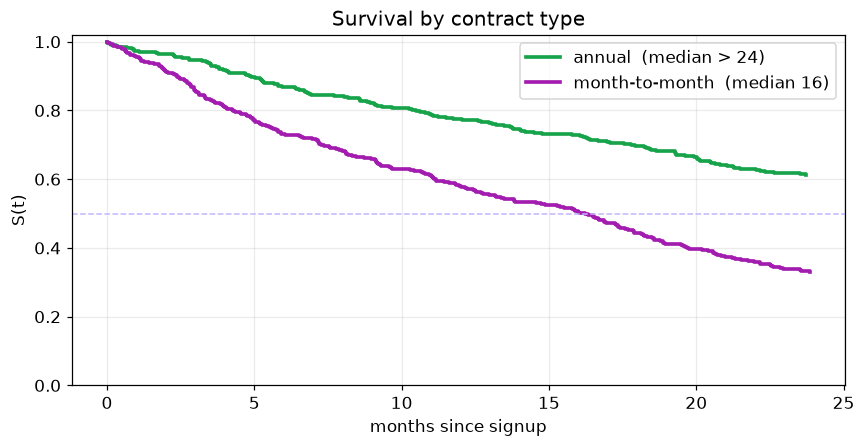


log-rank test: chi-square = 72.6, p = 0.00e+00  -> the curves differ


In [4]:
fig, ax = plt.subplots(figsize=(8, 4.2))
for g, col in [("annual", GR), ("month-to-month", FU)]:
    sub = df[df.contract==g]
    sf = SurvfuncRight(sub.tenure_months, sub.churned)
    ax.step(np.r_[0, sf.surv_times], np.r_[1, sf.surv_prob], where="post", color=col, lw=2.4, label=f"{g}  (median {median_surv(sf):.0f})" if not np.isnan(median_surv(sf)) else f"{g}  (median > 24)")
    print(f"{g:16s}: S(12mo) = {St(sf,12):.2f}, median = {median_surv(sf)}")
ax.axhline(0.5, color="#c4b5fd", ls="--", lw=1); ax.set_ylim(0, 1.02)
ax.set_xlabel("months since signup"); ax.set_ylabel("S(t)"); ax.set_title("Survival by contract type"); ax.legend()
plt.tight_layout(); plt.show()
chisq, p = survdiff(df.tenure_months, df.churned, df.contract)
print(f"\nlog-rank test: chi-square = {chisq:.1f}, p = {p:.2e}  -> the curves differ" if p < 0.05 else "no difference")

## DEMO 4 &middot; Cox proportional-hazards regression
The log-rank test compares groups; Cox regression *adjusts* and gives a hazard ratio per variable. HR > 1 means higher instantaneous churn risk. We standardize charges so its HR is per one standard deviation.

Cox hazard ratios:
  m2m         : HR = 2.24  95% CI [1.86, 2.71]  p = 6.0e-17
  charges_std : HR = 1.48  95% CI [1.35, 1.62]  p = 2.9e-17


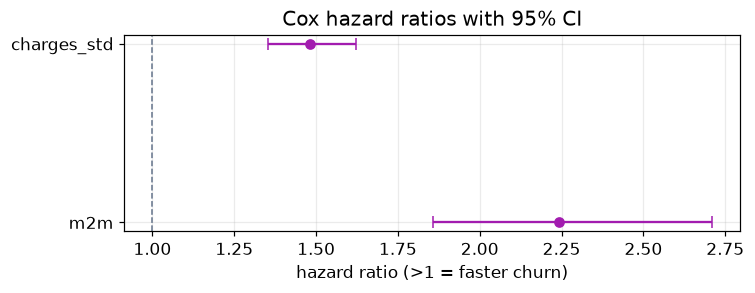

In [5]:
d = df.copy()
d["m2m"] = (d.contract=="month-to-month").astype(float)
d["charges_std"] = (d.monthly_charges - d.monthly_charges.mean()) / d.monthly_charges.std()
cox = PHReg.from_formula("tenure_months ~ m2m + charges_std", data=d, status=d.churned).fit()
names = cox.model.exog_names
hr = np.exp(np.asarray(cox.params)); ci = np.exp(np.asarray(cox.conf_int())); pv = np.asarray(cox.pvalues)
print("Cox hazard ratios:")
for i, nm in enumerate(names):
    print(f"  {nm:12s}: HR = {hr[i]:.2f}  95% CI [{ci[i,0]:.2f}, {ci[i,1]:.2f}]  p = {pv[i]:.1e}")
fig, ax = plt.subplots(figsize=(7, 2.8))
y = np.arange(len(names))
ax.errorbar(hr, y, xerr=[hr-ci[:,0], ci[:,1]-hr], fmt="o", color=FU, capsize=4)
ax.axvline(1, color="#64748b", ls="--", lw=1); ax.set_yticks(y); ax.set_yticklabels(names)
ax.set_xlabel("hazard ratio (>1 = faster churn)"); ax.set_title("Cox hazard ratios with 95% CI")
plt.tight_layout(); plt.show()

### Wrap-up
Censoring is a feature, not a defect. The Kaplan-Meier curve used all 1,000 customers (including the 513 still active) to estimate survival; the log-rank test confirmed month-to-month customers churn faster (**p < 0.0001**); and Cox put a number on it, **2.24x** the churn hazard for month-to-month and **1.48x** per standard deviation of monthly charges. Next in Part XXIV: **Structural Equation Modeling & Mixed Models**.